# CHAPTER 2 - PRACTICE 1: CLASSIFYING SPAM EMAILS

# Custom Multinomial Naive Bayes

## Mục tiêu

Trong notebook này, chúng ta xây dựng mô hình Multinomial Naive Bayes từ đầu (from scratch) để phân loại email Spam và Ham.

Các bước thực hiện gồm:

1. Giải thích lý thuyết Naive Bayes.
2. Xây dựng Custom Multinomial Naive Bayes.
3. Huấn luyện mô hình bằng tập dữ liệu đã tiền xử lý.
4. Hyperparameter Tuning bằng CustomGridSearchCV.
5. Cross Validation bằng CustomKFold.
6. Đánh giá mô hình bằng Accuracy, Precision, Recall và F1-Score.
7. Phân tích Confusion Matrix.
8. Tính toán TPR và FPR.
9. Lưu mô hình đã huấn luyện.

# 1. Lý thuyết Naive Bayes

Naive Bayes là một thuật toán học máy dựa trên định lý Bayes.

Ý tưởng chính:

- Mỗi email được biểu diễn bởi nhiều đặc trưng (features).
- Các đặc trưng được giả định là độc lập có điều kiện với nhau.
- Xác suất email thuộc lớp Spam hoặc Ham được tính dựa trên xác suất xuất hiện của các đặc trưng trong từng lớp.

Thuật toán sẽ chọn lớp có xác suất hậu nghiệm (Posterior Probability) lớn nhất.

# 2. Định lý Bayes

Định lý Bayes cho phép tính xác suất một email thuộc lớp Spam khi biết các đặc trưng của email.

Công thức:

P(C|X) = P(X|C) * P(C) / P(X)

Trong đó:

- P(C|X): Xác suất hậu nghiệm.
- P(X|C): Xác suất xuất hiện của đặc trưng khi biết lớp.
- P(C): Xác suất tiên nghiệm của lớp.
- P(X): Xác suất xuất hiện của dữ liệu.

# 3. Import thư viện

Trong phần này, chúng ta import các thư viện và các class cần thiết phục vụ cho quá trình huấn luyện mô hình.

Các thành phần chính bao gồm:

- Joblib: dùng để đọc dữ liệu đã được lưu dưới dạng .pkl.
- NumPy: hỗ trợ tính toán số học.
- Scikit-Learn Metrics: đánh giá hiệu suất mô hình.
- CustomMultinomialNB: mô hình Naive Bayes được xây dựng từ đầu.
- CustomKFold: thực hiện Cross Validation.
- CustomGridSearchCV: thực hiện Hyperparameter Tuning.
- save_model_package(): lưu mô hình sau khi huấn luyện.

In [10]:
# =====================================================
# Import thư viện
# =====================================================

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =====================================================
# Thêm đường dẫn project root
# =====================================================

import sys
import os

sys.path.append("..")

# =====================================================
# Import các class custom của project
# =====================================================

from utils.custom_multinomial_nb import CustomMultinomialNB

from utils.custom_cv import CustomKFold

from utils.custom_hyperparameter_tuning import (
    CustomGridSearchCV
)

from utils.model_manager import (
    save_model_package
)

# 4. Load dữ liệu

Dữ liệu đã được tiền xử lý và lưu dưới dạng file pickle.

Các file bao gồm:

- X_train_final.pkl
- X_test_final.pkl
- y_train.pkl
- y_test.pkl

Dữ liệu đặc trưng (X) đã được chuyển đổi sang dạng TF-IDF và lưu dưới dạng sparse matrix để tiết kiệm bộ nhớ.

In [11]:
# =====================================================
# Load dữ liệu
# =====================================================

X_train = joblib.load(
    "data/ready_for_train/X_train_final.pkl"
)

X_test = joblib.load(
    "data/ready_for_train/X_test_final.pkl"
)

y_train = joblib.load(
    "data/ready_for_train/y_train.pkl"
)

y_test = joblib.load(
    "data/ready_for_train/y_test.pkl"
)

# =====================================================
# Kiểm tra dữ liệu
# =====================================================

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (21906, 5001)
X_test : (5477, 5001)
y_train: (21906,)
y_test : (5477,)


# 5. Khởi tạo Cross Validation

Để đánh giá mô hình một cách khách quan hơn, ta sử dụng K-Fold Cross Validation.

Cross Validation giúp:

- Giảm sự phụ thuộc vào một lần chia dữ liệu.
- Đánh giá khả năng tổng quát hóa của mô hình.
- Hạn chế hiện tượng đánh giá thiên lệch.

Trong project này sử dụng CustomKFold do nhóm tự xây dựng.

In [12]:
# =====================================================
# Custom K Fold
# =====================================================

cv = CustomKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 6. Hyperparameter Tuning

Multinomial Naive Bayes có hai siêu tham số quan trọng:

## alpha

Hệ số Laplace Smoothing.

Mục đích:

- Tránh xác suất bằng 0.
- Tăng khả năng tổng quát hóa.

## fit_prior

Cho phép mô hình học xác suất tiên nghiệm từ dữ liệu hay không.

Giá trị:

- True: sử dụng phân phối thực tế của dữ liệu.
- False: giả định các lớp có xác suất như nhau.

Ta sử dụng Grid Search để tìm bộ tham số tối ưu.

In [13]:
# =====================================================
# Khởi tạo model
# =====================================================

nb_model = CustomMultinomialNB()

# =====================================================
# Grid Search Parameters
# =====================================================

param_grid = {

    "alpha": [
        0.01,
        0.1,
        0.5,
        1.0,
        2.0
    ],

    "fit_prior": [
        True,
        False
    ]
}

# 7. Huấn luyện mô hình bằng Grid Search

Mỗi bộ tham số sẽ được đánh giá bằng:

- 5 Fold Cross Validation
- F1 Score

F1 Score được chọn vì bài toán Spam Email thường quan tâm đồng thời Precision và Recall.

In [14]:
# =====================================================
# Grid Search CV
# =====================================================

grid_search = CustomGridSearchCV(

    estimator=nb_model,

    param_grid=param_grid,

    cv=cv,

    scoring="f1"
)

# =====================================================
# Training
# =====================================================

grid_search.fit(
    X_train,
    y_train
)

Bắt đầu GridSearchCV: 10 tổ hợp tham số, 5 folds.
[1/10] Params: {'alpha': 0.01, 'fit_prior': True} --> f1: 0.9759
[2/10] Params: {'alpha': 0.01, 'fit_prior': False} --> f1: 0.9763
[3/10] Params: {'alpha': 0.1, 'fit_prior': True} --> f1: 0.9756
[4/10] Params: {'alpha': 0.1, 'fit_prior': False} --> f1: 0.9760
[5/10] Params: {'alpha': 0.5, 'fit_prior': True} --> f1: 0.9746
[6/10] Params: {'alpha': 0.5, 'fit_prior': False} --> f1: 0.9750
[7/10] Params: {'alpha': 1.0, 'fit_prior': True} --> f1: 0.9742
[8/10] Params: {'alpha': 1.0, 'fit_prior': False} --> f1: 0.9749
[9/10] Params: {'alpha': 2.0, 'fit_prior': True} --> f1: 0.9740
[10/10] Params: {'alpha': 2.0, 'fit_prior': False} --> f1: 0.9743

-> Tham số TỐT NHẤT: {'alpha': 0.01, 'fit_prior': False}
-> Điểm f1 TỐT NHẤT: 0.9763


In [15]:
# =====================================================
# Kết quả tốt nhất
# =====================================================

print("Best Params:")
print(grid_search.best_params_)

print("\nBest F1:")
print(grid_search.best_score_)

Best Params:
{'alpha': 0.01, 'fit_prior': False}

Best F1:
0.9762675438788981


# 8. Mô hình tối ưu

Sau quá trình Hyperparameter Tuning, bộ tham số có điểm F1 cao nhất sẽ được lựa chọn.

Mô hình này sẽ được sử dụng để đánh giá trên tập kiểm tra (Test Set).

In [16]:
# =====================================================
# Best Model
# =====================================================

best_nb_model = grid_search.best_estimator_

# =====================================================
# Predict
# =====================================================

y_pred = best_nb_model.predict(
    X_test
)

# 9. Đánh giá mô hình

Sau khi tìm được bộ tham số tối ưu, mô hình sẽ được đánh giá trên tập Test Set.

Các độ đo được sử dụng:

## Accuracy

Tỷ lệ dự đoán đúng trên toàn bộ dữ liệu.

## Precision

Trong số các email được dự đoán là Spam, có bao nhiêu email thực sự là Spam.

## Recall

Trong số các email Spam thực sự, mô hình phát hiện được bao nhiêu email.

## F1-Score

Là trung bình điều hòa giữa Precision và Recall.

F1-Score đặc biệt phù hợp cho bài toán Spam Classification vì cần cân bằng giữa Precision và Recall.

In [17]:
# =====================================================
# Accuracy
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

# =====================================================
# Precision
# =====================================================

precision = precision_score(
    y_test,
    y_pred
)

# =====================================================
# Recall
# =====================================================

recall = recall_score(
    y_test,
    y_pred
)

# =====================================================
# F1 Score
# =====================================================

f1 = f1_score(
    y_test,
    y_pred
)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

MODEL PERFORMANCE
Accuracy : 0.9763
Precision: 0.9720
Recall   : 0.9780
F1 Score : 0.9750


# 10. Confusion Matrix

Confusion Matrix giúp quan sát chi tiết các dự đoán đúng và sai của mô hình.

Các thành phần:

- TP (True Positive)
- TN (True Negative)
- FP (False Positive)
- FN (False Negative)

Trong bài toán Spam Email:

Spam = 1

Ham = 0

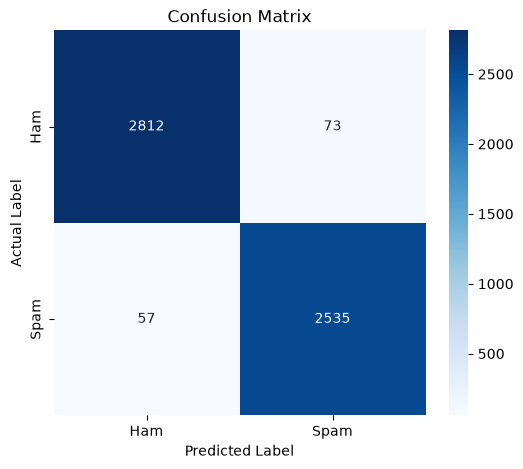

In [18]:
# =====================================================
# Confusion Matrix
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

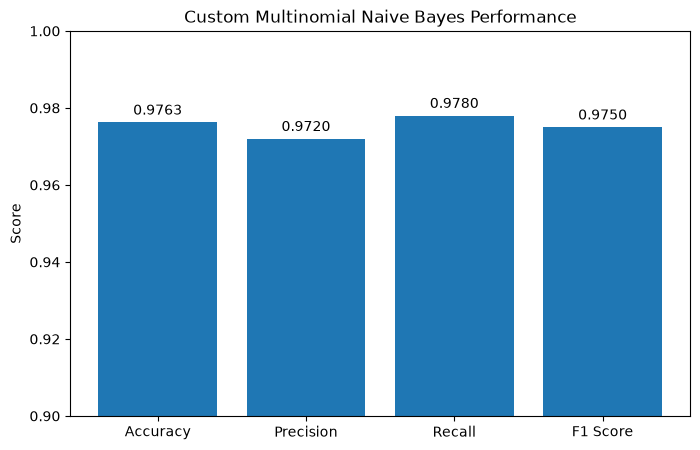

In [19]:
metrics_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

metrics_values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metrics_names,
    metrics_values
)

plt.ylim(0.90, 1.00)

plt.title(
    "Custom Multinomial Naive Bayes Performance"
)

plt.ylabel("Score")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center"
    )

plt.show()

In [20]:
# =====================================================
# Tách TP TN FP FN
# =====================================================

TN, FP, FN, TP = cm.ravel()

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

TP = 2535
TN = 2812
FP = 73
FN = 57


# 11. Ý nghĩa TP, TN, FP, FN

## True Positive (TP)

Email Spam được dự đoán đúng là Spam.

## True Negative (TN)

Email Ham được dự đoán đúng là Ham.

## False Positive (FP)

Email Ham nhưng bị dự đoán nhầm thành Spam.

Đây là lỗi khá nghiêm trọng vì email hợp lệ có thể bị chuyển vào thư mục Spam.

## False Negative (FN)

Email Spam nhưng bị dự đoán nhầm thành Ham.

Đây là trường hợp Spam lọt qua bộ lọc.

# 12. TPR và FPR

Hai chỉ số quan trọng để đánh giá khả năng phát hiện Spam của mô hình:

## TPR (True Positive Rate)

Cho biết mô hình phát hiện được bao nhiêu phần trăm email Spam thực sự.

TPR càng cao càng tốt.

## FPR (False Positive Rate)

Cho biết mô hình dự đoán nhầm bao nhiêu email Ham thành Spam.

FPR càng thấp càng tốt.

In [21]:
# =====================================================
# True Positive Rate
# =====================================================

TPR = TP / (TP + FN)

# =====================================================
# False Positive Rate
# =====================================================

FPR = FP / (FP + TN)

print("TPR =", round(TPR, 4))
print("FPR =", round(FPR, 4))

TPR = 0.978
FPR = 0.0253


# 13. Phân tích TPR và FPR

## Nếu TPR cao

Điều này cho thấy mô hình phát hiện được phần lớn email Spam.

Spam ít có khả năng lọt vào hộp thư đến.

## Nếu FPR thấp

Điều này cho thấy rất ít email hợp lệ bị đánh dấu nhầm là Spam.

Người dùng sẽ không bỏ lỡ các email quan trọng.

Một mô hình Spam Classification tốt thường có:

- TPR cao
- FPR thấp

để cân bằng giữa khả năng phát hiện Spam và trải nghiệm người dùng.

# 14. Lưu mô hình

Sau khi hoàn thành huấn luyện và đánh giá, mô hình sẽ được lưu lại để sử dụng trong tương lai.

In [22]:
# =====================================================
# Metrics Dictionary
# =====================================================

metrics = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1_Score": f1,

    "TPR": TPR,

    "FPR": FPR
}

In [23]:
# =====================================================
# Save Model
# =====================================================

model_path = save_model_package(

    model=best_nb_model,

    model_name="Custom Multinomial Naive Bayes",

    best_params=grid_search.best_params_,

    metrics=metrics
)

print("Saved:", model_path)

Saved: models\Custom_Multinomial_Naive_Bayes.pkl


# 15. Kết luận

Trong notebook này, chúng ta đã xây dựng thành công mô hình Custom Multinomial Naive Bayes để phân loại email Spam.

Các bước thực hiện:

- Xây dựng mô hình từ đầu.
- Huấn luyện bằng dữ liệu đã tiền xử lý.
- Thực hiện Hyperparameter Tuning bằng CustomGridSearchCV.
- Đánh giá bằng Accuracy, Precision, Recall và F1-Score.
- Phân tích Confusion Matrix.
- Tính toán TPR và FPR.
- Lưu mô hình để sử dụng về sau.

Kết quả thu được sẽ được sử dụng trong notebook so sánh mô hình để lựa chọn thuật toán phù hợp nhất cho bài toán Spam Email Classification.